# Calibración de modelos

Objetivo

De acuerdo al analisis realizado en el EDA y los resultados obtenidos en los modelos que se compararon, donde la feature a predecir es clave y es un modelo donde la clasificacion incorrecta es critica (es decir un falso negativo es mas importante que un falso positivo). Al tener clases desbalanceadas es posible que aplicando cualquier modelo, las predicciones puede que no sean muy buenas y cualquier variacion en los resultados es clave para tomar decisiones y determinar si el modelo seleccionado es el correcto. Es por eso que creemos que seria importante analizar la calibracion del o los modelos seleccionados.

Varios de los modelos analizados tuvieron un buen rendimiento incluso similares entre si, Random Forest, Gradient Boosting, SVM.

Es por eso que vamos a medir la calibracion para tener una idea de la incertidumbre del modelo.

Seleccionamos Random Forest ya que es el modelo que mejores resultados obtuvo en las metricas.


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import seaborn as sns

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

from sklearn.calibration import CalibrationDisplay, calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss, accuracy_score, f1_score, mean_absolute_error, r2_score, root_mean_squared_error, mean_absolute_percentage_error, fbeta_score, make_scorer, recall_score, precision_score, classification_report, roc_auc_score, confusion_matrix

from sklearn.pipeline import make_pipeline, Pipeline
from imblearn.over_sampling import SMOTE


In [16]:
decision_tree_tuned = joblib.load('../models/decision_tree_tuned.pkl')
random_forest_tuned = joblib.load('../models/random_forest_tuned.pkl')
xgboost_tuned = joblib.load('../models/xgboost_tuned.pkl')
svm = joblib.load('../models/svc_tuned.pkl')
data = joblib.load('../data/processed_data.pkl')
columns = data['feature_names']
X_train = pd.DataFrame(data['X_train'], columns=columns)
X_test = pd.DataFrame(data['X_test'], columns=columns)
X_val = pd.DataFrame(data['X_val'], columns=columns)
y_train = data['y_train']
y_test = data['y_test']
y_val = data['y_val']

## Analisis modelo Random Forest

Para empezar verificamos como se comporta el modelo vs sus versiones calibradas con los metodos isotonic y pratt. 

Sabemos que si hay pocas muestras de la clase minoritaria, el calibrador (isotónico o sigmoide) tendrá dificultades para ajustar la curva de calibración, lo que podria llevar a calibraciones poco fiables. 

En conjuntos de datos muy desequilibrados, la calibración sigmoide suele ser preferible ya que es más robusta cuando hay pocas muestras de la clase minoritaria, ayudando a ajustar los límites de decisión sesgados hacia la clase mayoritaria. 

Mientras que la calibración isotónica tiende a sobreajustar (overfitting)

In [17]:
model_calibrate = random_forest_tuned

In [18]:
model_platt = CalibratedClassifierCV(
        estimator=model_calibrate,
        method='sigmoid', cv=3, ensemble=True
    )
model_platt.fit(X_train, y_train)

model_iso = CalibratedClassifierCV(
        estimator=model_calibrate,
        method='isotonic', cv=3, ensemble=True
    )
model_iso.fit(X_train, y_train)

y_probs_platt = model_platt.predict_proba(X_val)[:, 1]
y_probs_iso = model_iso.predict_proba(X_val)[:, 1]
y_pred_proba = model_calibrate.predict_proba(X_val)[:, 1]

/Users/alejandrovalle/Desktop/Posgrado/CEIA/2do_bimestre/aprendizaje_de_maquina/ML/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


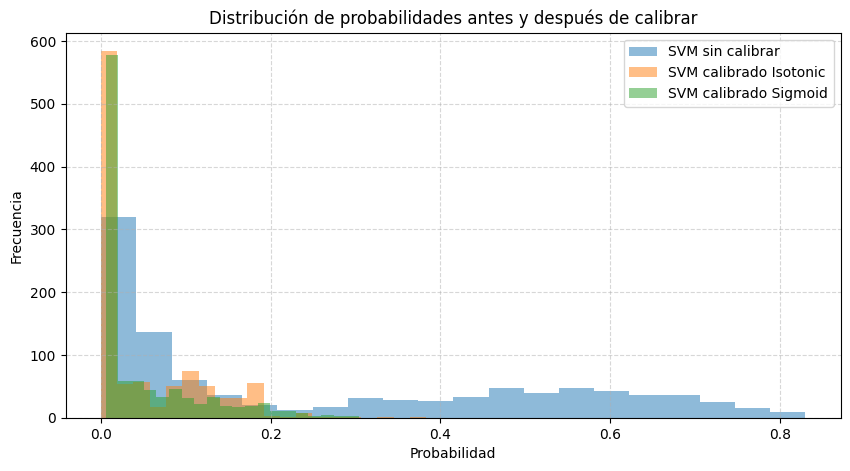

In [19]:
plt.figure(figsize=(10, 5))

# modelo sin calibrar
plt.hist(y_pred_proba, bins=20, alpha=0.5, label="SVM sin calibrar")

# modelo calibrado con Isotonic
plt.hist(y_probs_iso, bins=20, alpha=0.5, label="SVM calibrado Isotonic")

plt.hist(y_probs_platt, bins=20, alpha=0.5, label="SVM calibrado Sigmoid")

plt.xlabel("Probabilidad")
plt.ylabel("Frecuencia")
plt.title("Distribución de probabilidades antes y después de calibrar")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Podemos ver que la frecuencia de probabilidades para detectar un infarto son pocas, es decir que la mayoria de las veces no se van a detectar, no porque el modelo sea malo, sino porque existe un desbalance y en la realidad los casos son pocos. 

Tambien vemos un claro desbalance en los modelos calibrados.

Veamos las metricas de los modelos y el comportamiento de las predicciones originales vs las calibradas.

In [20]:
def resumen_calibracion(y, probs, pred):
    return {
        "Brier": brier_score_loss(y, probs),
        "LogLoss": log_loss(y, probs),
        "Recall": recall_score(y, pred),
    }

y_pred_platt = model_platt.predict(X_val)
y_pred_iso = model_iso.predict(X_val)
y_pred = model_calibrate.predict(X_val)

modelos = {
    "Modelo (sin calibrar)": [y_pred_proba,  y_pred],
    "Modelo + Isotonic":     [y_probs_iso,   y_pred_iso],
    "Modelo + Sigmoid":      [y_probs_platt, y_pred_platt],
}

/Users/alejandrovalle/Desktop/Posgrado/CEIA/2do_bimestre/aprendizaje_de_maquina/ML/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


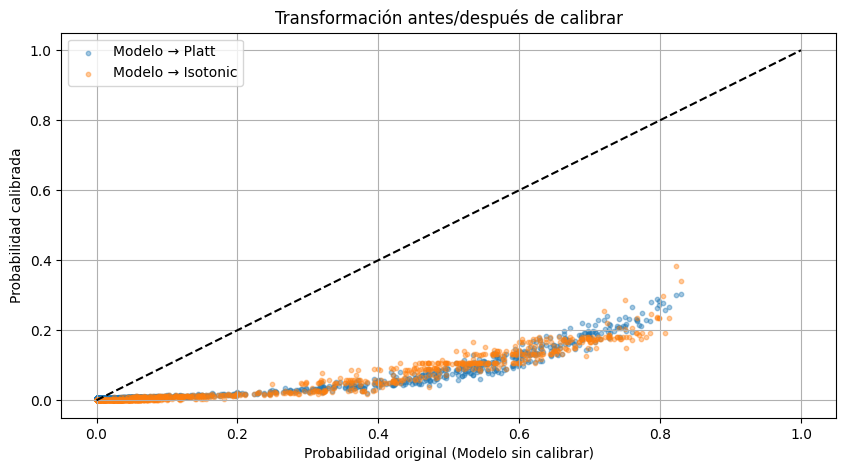

In [21]:
plt.figure(figsize=(10, 5))

plt.scatter(y_pred_proba, y_probs_platt, s=10, alpha=0.4, label="Modelo → Platt")
plt.scatter(y_pred_proba, y_probs_iso, s=10, alpha=0.4, label="Modelo → Isotonic")

plt.plot([0,1],[0,1],'k--') 
plt.xlabel("Probabilidad original (Modelo sin calibrar)")
plt.ylabel("Probabilidad calibrada")
plt.title("Transformación antes/después de calibrar")
plt.legend()
plt.grid(True)
plt.show()

In [22]:
print(pd.DataFrame({k: resumen_calibracion(y_val, v[0], v[1]) for k,v in modelos.items()}).T)

                          Brier   LogLoss  Recall
Modelo (sin calibrar)  0.127465  0.376990    0.74
Modelo + Isotonic      0.042885  0.286896    0.00
Modelo + Sigmoid       0.042613  0.165375    0.00


Segun las metricas, Random forest tiene buena calibracion, mientras que los modelos calibrados tienen excelente calibracion. Esto puede ser sesgado por el desbalance entre las clases, lo podemos ver en Recall.

Por otro lado, LogLoss nos indica que Random Forest tiene mejor prediccion que el resto de los modelos calibrados.

Brier podria no ser muy confiable como metrica de medicion.

Veamos la curva de calibracion

In [23]:
def plot_calibration(y_true, probs_dict, title="Curva de calibración", size=(9,6)):
    plt.figure(figsize=size)
    plt.plot([0, 1], [0, 1], "k--", label="Perfectamente calibrado")

    colors = plt.cm.Dark2.colors 
    
    for i, (name, prob) in enumerate(probs_dict.items()):
        color = colors[i % len(colors)]
        
        frac_pos, mean_pred = calibration_curve(
            y_true, prob, n_bins=10, strategy='uniform'
        )
        brier = brier_score_loss(y_true, prob)
        ll = log_loss(y_true, prob)
        recall = recall_score(y_true, prob >= 0.5)

        plt.plot(mean_pred, frac_pos, marker="o", color=color, linewidth=2,
                 label=f"{name}\nBrier={brier:.3f} | LogLoss={ll:.3f} | Recall={recall:.3f}")

    plt.xlabel("Probabilidad predicha media")
    plt.ylabel("Fracción de positivos reales")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()

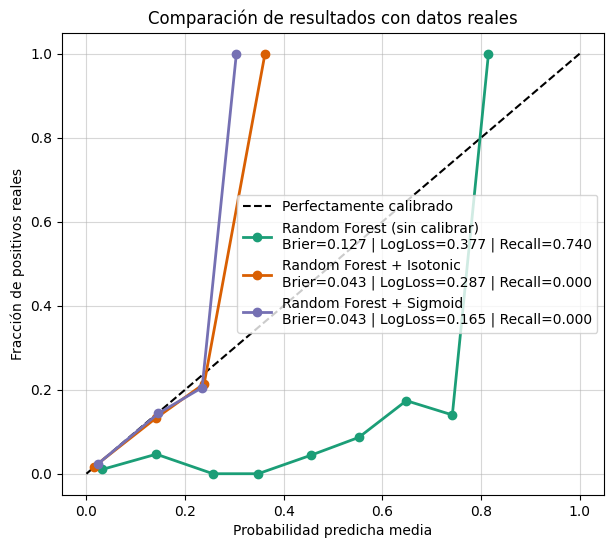

In [24]:
probs = {
    "Random Forest (sin calibrar)": y_pred_proba,
    "Random Forest + Isotonic": y_probs_iso,
    "Random Forest + Sigmoid": y_probs_platt
}

plot_calibration(y_val, probs, "Comparación de resultados con datos reales", size=(7,6))

Segun la curva, las calibracion en los modelos calibrados en predicciones de que no sean infartos trabaja bien hasta en probabilidades del 20%. Pero luego aumenta fuertemente para probabilidades muy bajas, lo que indica que no cuanta con buena calibracion para la clase minoritaria (tal como se analizo previamente)

Mientras que para Random Forest la curva esta muy pegada a cero al principio y luego aumenta fuertemente. Esto indica que para probabilidades del 70% detectara la clase mayoritaria, y hasta un 80 % la clase mayoritaria.


Hagamos una prueba aplicando Smote para ver como se comporta el modelo con oversampling

In [25]:
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

model_calibrate.fit(X_resampled, y_resampled)

model_platt = CalibratedClassifierCV(
        estimator=model_calibrate,
        method='sigmoid', cv=3, ensemble=True
    )
model_platt.fit(X_resampled, y_resampled)

model_iso = CalibratedClassifierCV(
        estimator=model_calibrate,
        method='isotonic', cv=3, ensemble=True
    )

model_iso.fit(X_resampled, y_resampled)

y_probs_platt_with_resampled = model_platt.predict_proba(X_val)[:, 1]
y_probs_iso_with_resampled = model_iso.predict_proba(X_val)[:, 1]
y_pred_proba_with_resampled = model_calibrate.predict_proba(X_val)[:, 1]

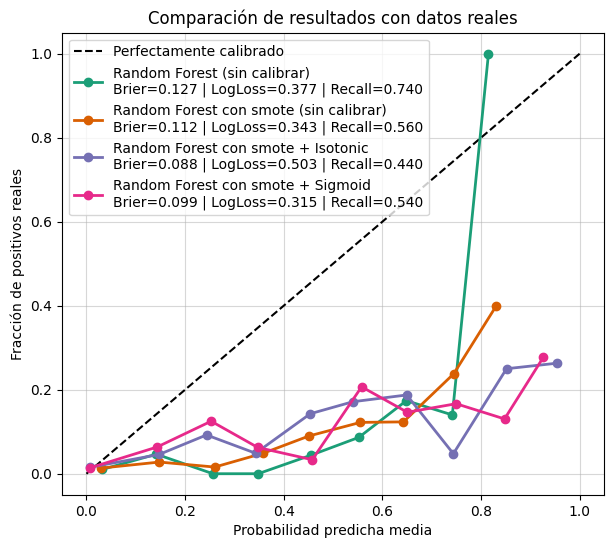

In [26]:
probs = {
    "Random Forest (sin calibrar)": y_pred_proba,
    "Random Forest con smote (sin calibrar)": y_pred_proba_with_resampled,
    "Random Forest con smote + Isotonic": y_probs_iso_with_resampled,
    "Random Forest con smote + Sigmoid": y_probs_platt_with_resampled
}

plot_calibration(y_val, probs, "Comparación de resultados con datos reales", size=(7,6))

Vemos que los modelos calibrados funcionan mejor, a pesar de que la curva se encuentra mas pegada a cero.

## Conclusion

Al analizar Random Forest con sus pares calibrados sobre un modelo fuertemente desbalanceado podemos concluir que las calibraciones no ayudan a mejorar el modelo, por el contrario lo empeoraron. No porque el calibrado no se aplique correctamente, sino por el desbalance mismo. Lo podemos ver en las metricas, mientras que Brier indica una falsa buena calibracion para los modelos calibrados, LogLoss y Recall indican lo contrario.

Podemos ver tambien que al intentar atacar el desbalance antes de calibrar cambia los resultados de la calibracion, mejorando mucho los modelos calibrados ,pero las metricas aun no son mejores que en el modelo original.

Calibrar Random Forest sobre datos desbalanceado es crucial para obtener una buena calibracion.

Aun asi Random Forest sin aplicar oversamplig y sin calibrar predice mejor

## Comparación final en validation

Para cerrar, comparamos las cuatro versiones candidatas sobre `X_val` con las mismas métricas que usamos en el nb02 (F2, Recall, Precision, AUC-ROC, PR-AUC):

- **Random Forest base** (del nb02)
- **Random Forest + Sigmoid** (calibración Platt, sin SMOTE)
- **Random Forest + Isotonic** (calibración isotónica, sin SMOTE)
- **Mejor ensamble por votación** (del nb03)


In [27]:
from sklearn.metrics import average_precision_score
import os

BETA = 2
METRIC_NAME = f'F{BETA}'

# Recargar RF tuneado original (la celda de SMOTE sobreescribió random_forest_tuned en memoria)
rf_base = joblib.load('../models/random_forest_tuned.pkl')

# Re-fit calibradores sin SMOTE, sobre el RF original
rf_sigmoid = CalibratedClassifierCV(estimator=rf_base, method='sigmoid', cv=3, ensemble=True)
rf_sigmoid.fit(X_train, y_train)

rf_isotonic = CalibratedClassifierCV(estimator=rf_base, method='isotonic', cv=3, ensemble=True)
rf_isotonic.fit(X_train, y_train)

# Cargar mejor ensamble del nb04
ensemble_path = '../models/best_ensemble.pkl'
ensemble_obj = joblib.load(ensemble_path) if os.path.exists(ensemble_path) else None

candidates = {
    'Random Forest (base)':     rf_base,
    'Random Forest + Sigmoid':  rf_sigmoid,
    'Random Forest + Isotonic': rf_isotonic,
}
if ensemble_obj is not None and not isinstance(ensemble_obj, dict):
    candidates['Mejor ensamble (nb04)'] = ensemble_obj

print('Candidatos cargados:')
for name in candidates:
    print(f'  - {name}')

Candidatos cargados:
  - Random Forest (base)
  - Random Forest + Sigmoid
  - Random Forest + Isotonic
  - Mejor ensamble (nb04)


In [28]:
def metrics_row(name, model, X, y):
    y_pred = model.predict(X)
    row = {
        'Modelo':    name,
        'F1':        f1_score(y, y_pred, zero_division=0),
        METRIC_NAME: fbeta_score(y, y_pred, beta=BETA, zero_division=0),
        'Recall':    recall_score(y, y_pred, zero_division=0),
        'Precision': precision_score(y, y_pred, zero_division=0),
    }
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X)[:, 1]
        row['AUC-ROC'] = roc_auc_score(y, y_prob)
        row['PR-AUC']  = average_precision_score(y, y_prob)
    else:
        row['AUC-ROC'] = np.nan
        row['PR-AUC']  = np.nan
    return row

final_val_df = (
    pd.DataFrame([metrics_row(name, m, X_val, y_val) for name, m in candidates.items()])
    .set_index('Modelo')
    .sort_values(METRIC_NAME, ascending=False)
)
display(final_val_df.style.highlight_max(axis=0).format('{:.4f}'))

final_winner_name = final_val_df[METRIC_NAME].idxmax()
print(f'\nGanador final por {METRIC_NAME} en val: {final_winner_name} '
      f'({METRIC_NAME}={final_val_df.loc[final_winner_name, METRIC_NAME]:.4f}, '
      f'Recall={final_val_df.loc[final_winner_name, "Recall"]:.4f})')

/Users/alejandrovalle/Desktop/Posgrado/CEIA/2do_bimestre/aprendizaje_de_maquina/ML/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/alejandrovalle/Desktop/Posgrado/CEIA/2do_bimestre/aprendizaje_de_maquina/ML/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/alejandrovalle/Desktop/Posgrado/CEIA/2do_bimestre/aprendizaje_de_maquina/ML/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/alejandrovalle/Desktop/Posgrado/CEIA/2do_bimestre/aprendizaje_de_maquina/ML/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


,F1,F2,Recall,Precision,AUC-ROC,PR-AUC
Modelo,,,,,,
Random Forest (base),0.2458,0.4102,0.7400,0.1474,0.8071,0.2589
Mejor ensamble (nb04),0.2410,0.4048,0.7400,0.1440,nan,nan
Random Forest + Sigmoid,0.0000,0.0000,0.0000,0.0000,0.8049,0.2223
Random Forest + Isotonic,0.0000,0.0000,0.0000,0.0000,0.7952,0.2118



Ganador final por F2 en val: Random Forest (base) (F2=0.4102, Recall=0.7400)
